In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# EDA

In [2]:
df = pd.read_csv("london_merged.csv")
print("Shape: ", df.shape)
print("Columns: ", df.columns)
print("İnformations: ")
df.info()
print("İsnull Values: \n", df.isnull().sum())
display(df.head())
display(df.describe())

Shape:  (17414, 10)
Columns:  Index(['timestamp', 'cnt', 't1', 't2', 'hum', 'wind_speed', 'weather_code',
       'is_holiday', 'is_weekend', 'season'],
      dtype='object')
İnformations: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17414 entries, 0 to 17413
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   timestamp     17414 non-null  object 
 1   cnt           17414 non-null  int64  
 2   t1            17414 non-null  float64
 3   t2            17414 non-null  float64
 4   hum           17414 non-null  float64
 5   wind_speed    17414 non-null  float64
 6   weather_code  17414 non-null  float64
 7   is_holiday    17414 non-null  float64
 8   is_weekend    17414 non-null  float64
 9   season        17414 non-null  float64
dtypes: float64(8), int64(1), object(1)
memory usage: 1.3+ MB
İsnull Values: 
 timestamp       0
cnt             0
t1              0
t2              0
hum             0
wind_speed      0

,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0
4,2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0


,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
count,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000
mean,1143.101642,12.468091,11.520836,72.324954,15.913063,2.722752,0.022051,0.285403,1.492075
std,1085.108068,5.571818,6.615145,14.313186,7.894570,2.341163,0.146854,0.451619,1.118911
min,0.000000,-1.500000,-6.000000,20.500000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,257.000000,8.000000,6.000000,63.000000,10.000000,1.000000,0.000000,0.000000,0.000000
50%,844.000000,12.500000,12.500000,74.500000,15.000000,2.000000,0.000000,0.000000,1.000000
75%,1671.750000,16.000000,16.000000,83.000000,20.500000,3.000000,0.000000,1.000000,2.000000
max,7860.000000,34.000000,34.000000,100.000000,56.500000,26.000000,1.000000,1.000000,3.000000


In [3]:
mapping_season = {
    0:"spring",
    1:"summer",
    2:"fall",
    3:"winter"
}
mapping_wthc = {
    1:"clear",
    2:"scattered_clouds",
    3:"broken_clouds",
    4:"cloudy",
    7:"rain",
    10:"rain_with_thunderstorm",
    26:"snowfall",
    94:"freezing_fog"
}
df_enc = df.copy()
df_enc["season"] = df_enc["season"].map(mapping_season)
df_enc["weather_code"] = df_enc["weather_code"].map(mapping_wthc)

In [4]:
df_enc.head()

,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,broken_clouds,0.0,1.0,winter
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,clear,0.0,1.0,winter
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,clear,0.0,1.0,winter
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,clear,0.0,1.0,winter
4,2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,clear,0.0,1.0,winter


In [5]:
for i in ["is_holiday", "is_weekend", "season"]:
    print(i)
    print("Uniques: ", df_enc[i].unique())
    print("Values: \n", df_enc[i].value_counts())

is_holiday
Uniques:  [0. 1.]
Values: 
 is_holiday
0.0    17030
1.0      384
Name: count, dtype: int64
is_weekend
Uniques:  [1. 0.]
Values: 
 is_weekend
0.0    12444
1.0     4970
Name: count, dtype: int64
season
Uniques:  ['winter' 'spring' 'summer' 'fall']
Values: 
 season
spring    4394
summer    4387
winter    4330
fall      4303
Name: count, dtype: int64


In [6]:
numerical = [i for i in df_enc.columns if df_enc[i].dtype !="O" and i !="is_holiday" and i!="is_weekend"]
categorical = [k for k in df_enc.columns if df_enc[k].dtype == "O"]
categorical.append("is_holiday")
categorical.append("is_weekend")
categorical.remove("timestamp")

In [7]:
print(numerical)
print(categorical)

['cnt', 't1', 't2', 'hum', 'wind_speed']
['weather_code', 'season', 'is_holiday', 'is_weekend']


In [8]:
def see_numerical(columns):
    
    fig, ax = plt.subplots(2,3,figsize=(20,10))
    ax = ax.flatten()
    for i, col in enumerate(columns):
        sns.kdeplot(
            data = df_enc,
            x = col,
            ax = ax[i]
        )
        ax[i].set_title(f"{col} Distribution")

    for i in range(i+1, len(ax)):
        ax[i].axis("off")
    
    plt.tight_layout()
    plt.show()

    fig2, ax2 = plt.subplots(2,3,figsize=(20,10))
    ax2 = ax2.flatten()
    for k, col in enumerate(columns):
        sns.boxplot(
            data = df_enc,
            y = col,
            ax = ax2[k]
        )
        ax2[k].set_title(f"{col} Boxplot")
    
    for k in range(k+1, len(ax)):
        ax2[k].axis("off")
    
    plt.tight_layout()
    plt.show()

def see_categorical(columns):
    fig, ax = plt.subplots(2,3,figsize=(20,10))
    ax = ax.flatten()
    for k, col in enumerate(columns):
        sns.histplot(
            data = df_enc,
            y = col,
            ax = ax[k]
        )
        ax[k].set_title(f"{col} Barplot")

    for k in range(k+1, len(ax)):
        ax[k].axis("off")

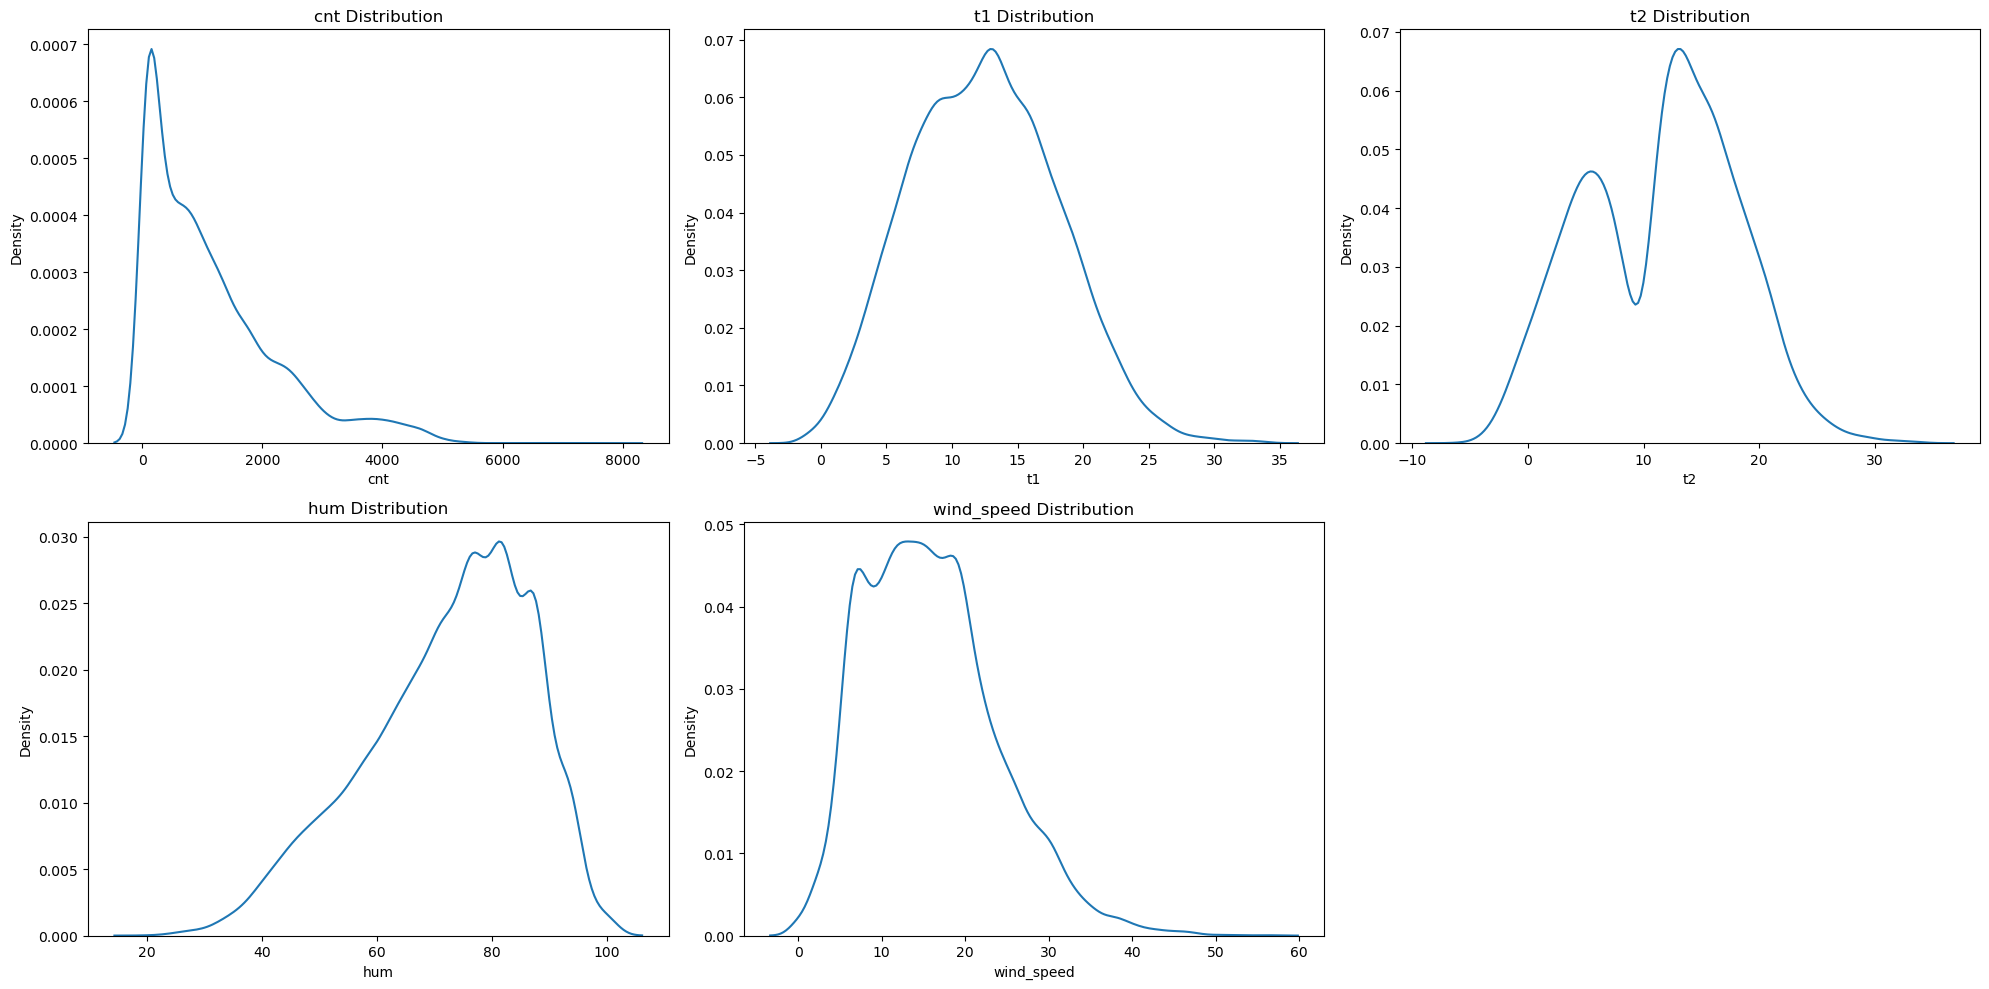

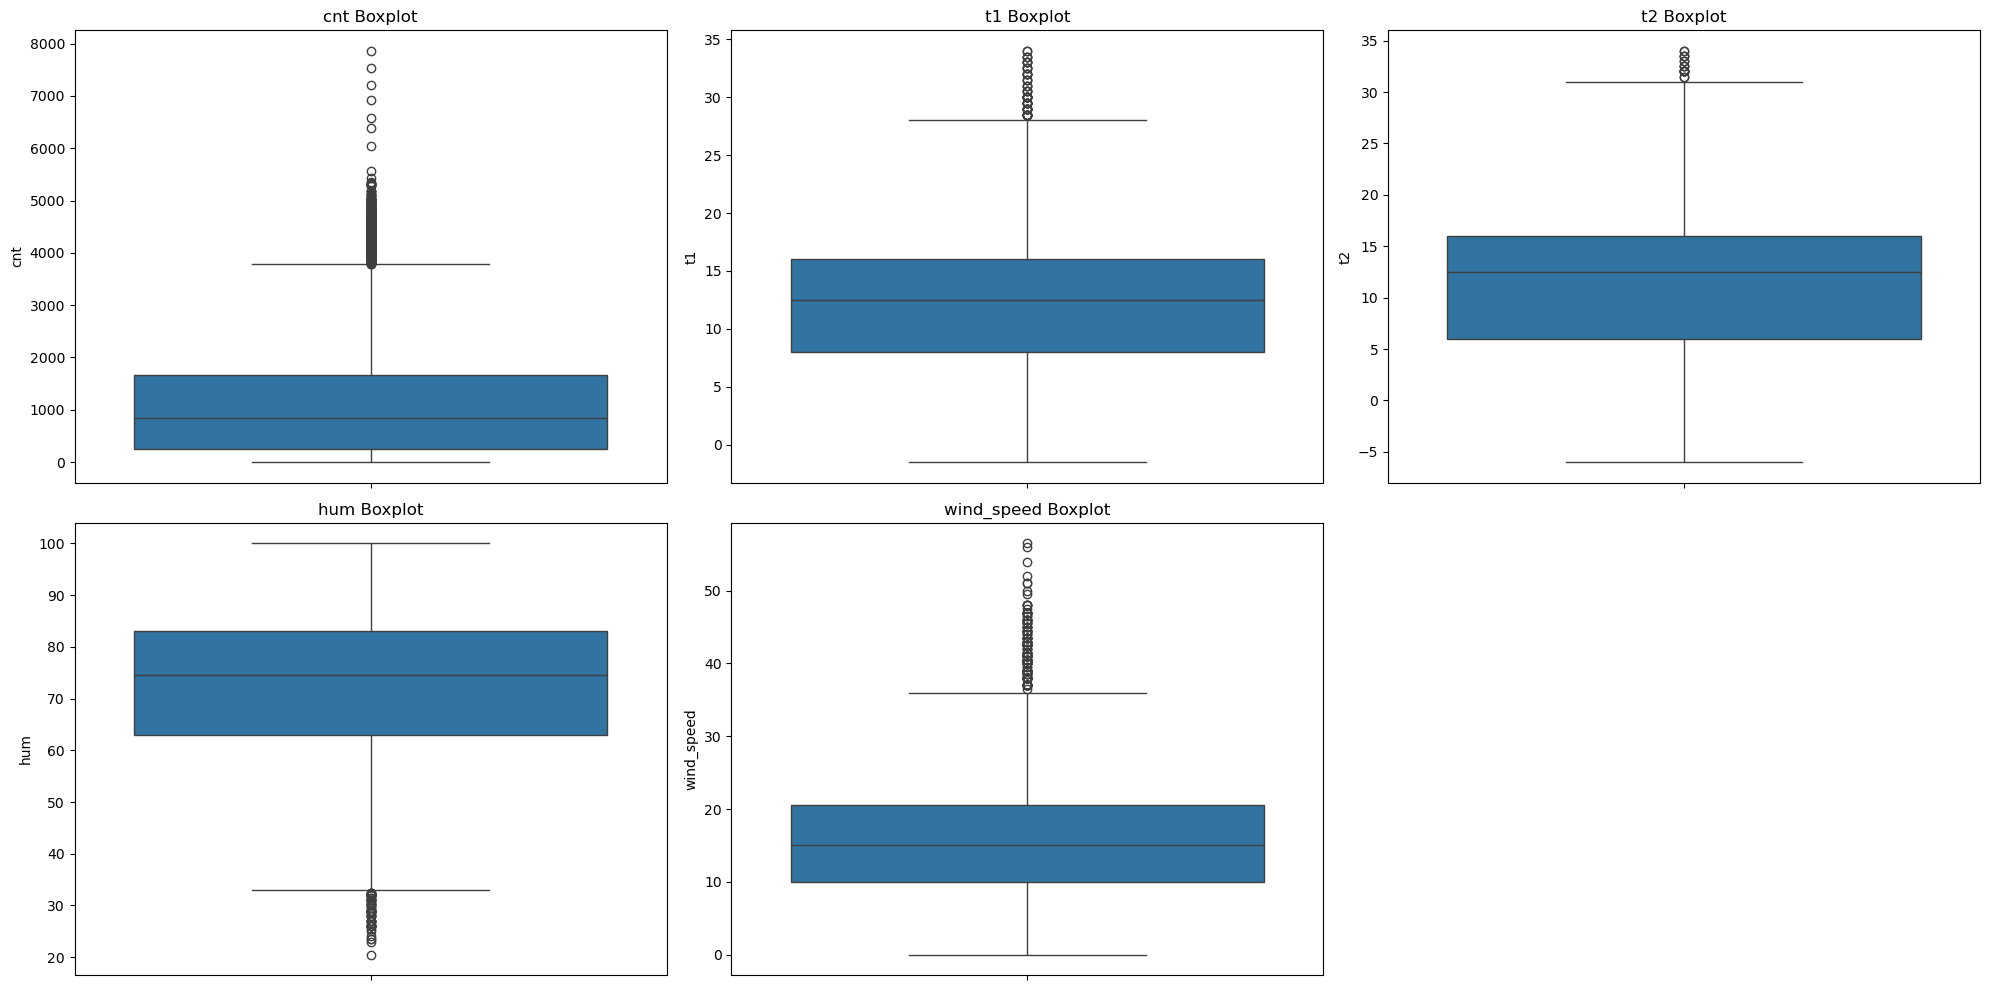

In [9]:
see_numerical(numerical)

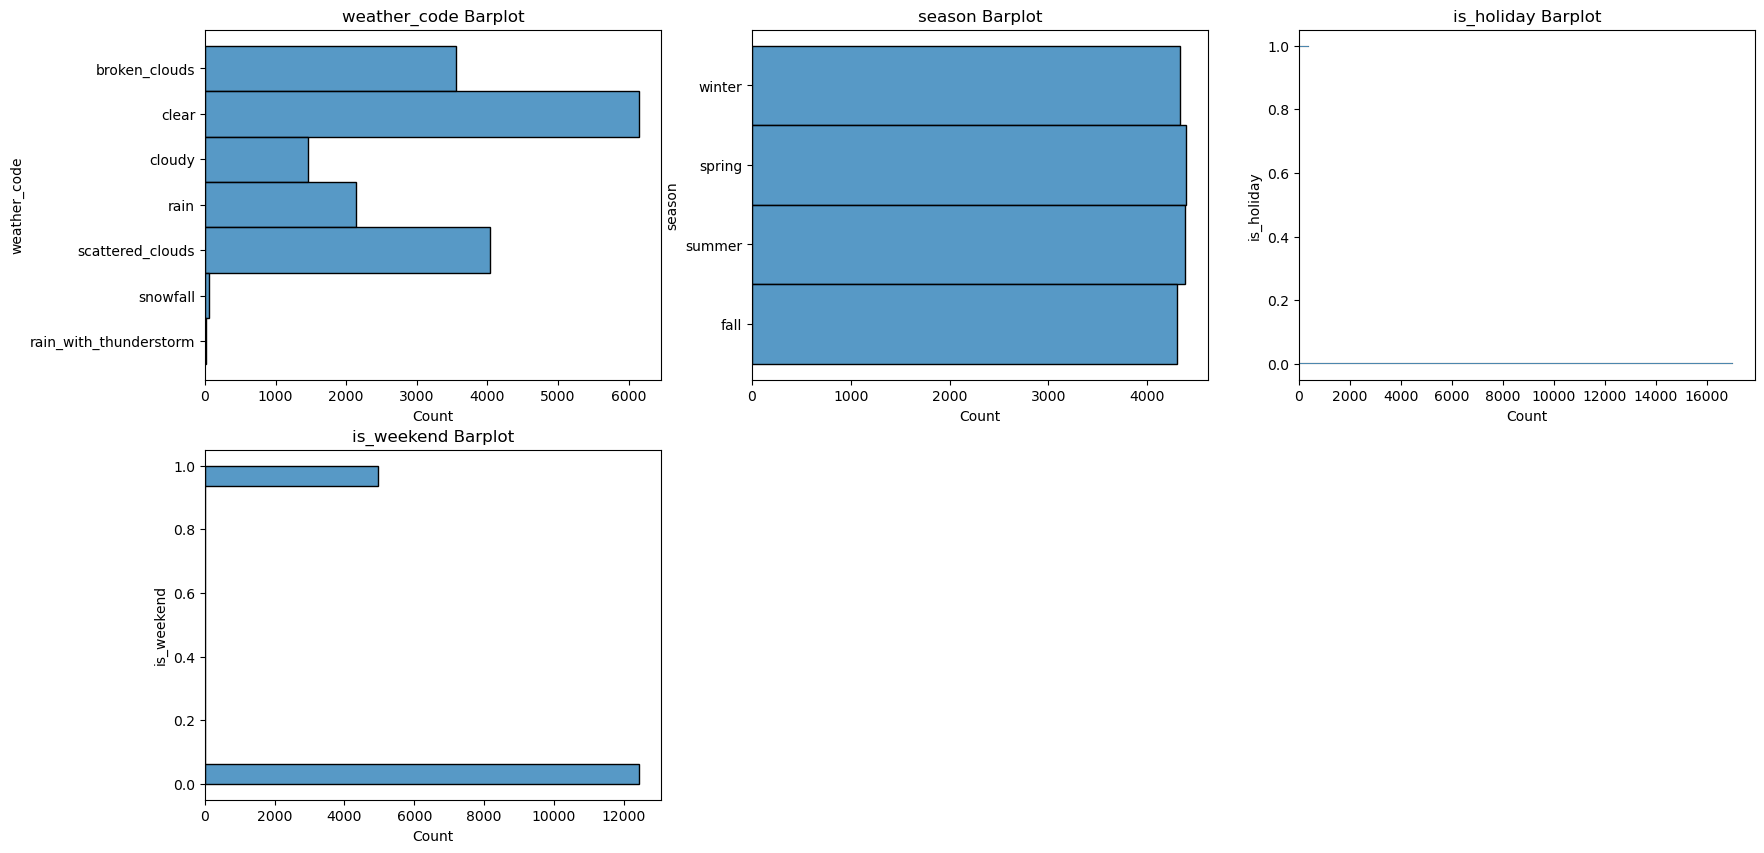

In [10]:
see_categorical(categorical)

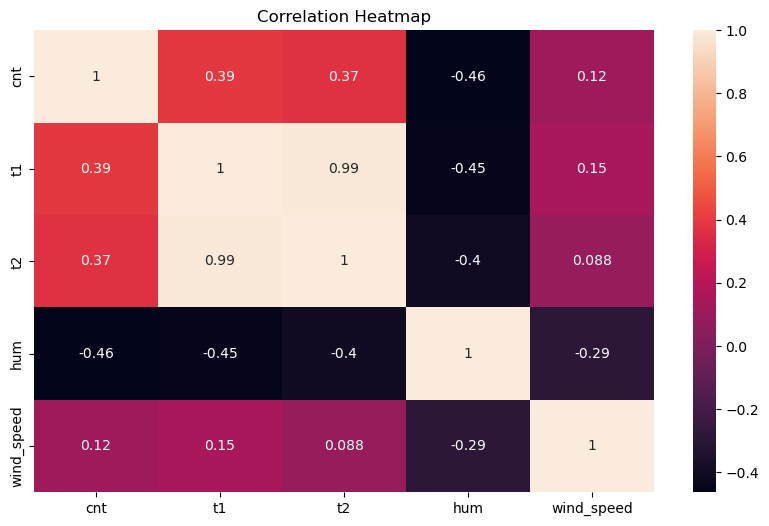

In [11]:
plt.figure(figsize=(10,6))
corr = df_enc.drop(["is_holiday", "is_weekend"], axis=1).corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

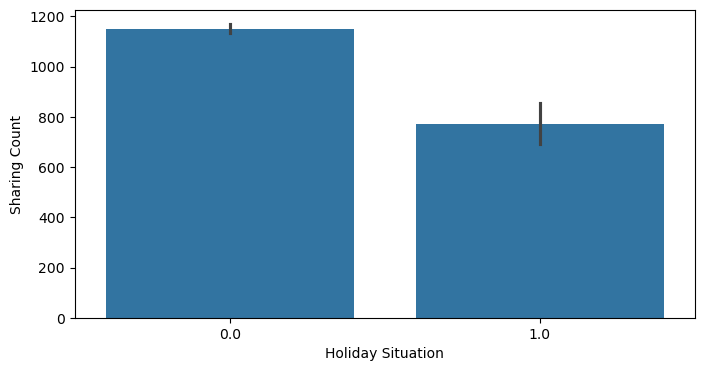

In [12]:
plt.figure(figsize=(8,4))
sns.barplot(x="is_holiday", y="cnt", data=df_enc, estimator="mean")
plt.xlabel("Holiday Situation")
plt.ylabel("Sharing Count")
plt.show()

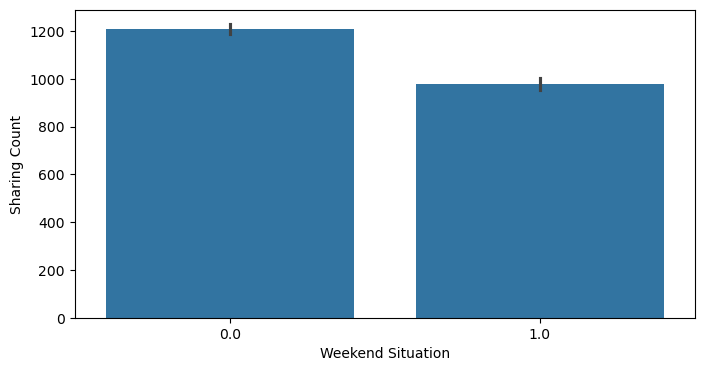

In [13]:
plt.figure(figsize=(8,4))
sns.barplot(x="is_weekend", y="cnt", data=df_enc, estimator="mean")
plt.xlabel("Weekend Situation")
plt.ylabel("Sharing Count")
plt.show()

# Feature Engineering

In [14]:
df_enc.drop("timestamp", axis=1, inplace=True)

In [15]:
df_enc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17414 entries, 0 to 17413
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cnt           17414 non-null  int64  
 1   t1            17414 non-null  float64
 2   t2            17414 non-null  float64
 3   hum           17414 non-null  float64
 4   wind_speed    17414 non-null  float64
 5   weather_code  17414 non-null  object 
 6   is_holiday    17414 non-null  float64
 7   is_weekend    17414 non-null  float64
 8   season        17414 non-null  object 
dtypes: float64(6), int64(1), object(2)
memory usage: 1.2+ MB


In [16]:
from sklearn.model_selection import train_test_split
X = df_enc.drop("cnt", axis=1)
y = df_enc["cnt"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

In [17]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
cols = ["weather_code", "season"]
encoder = OneHotEncoder(drop="first", handle_unknown="ignore")
preprocessor = ColumnTransformer(
    transformers = [
        ("cat", encoder, cols)
    ],
    remainder="passthrough"
)
X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)
columns = preprocessor.get_feature_names_out()
X_train_enc = pd.DataFrame(X_train_enc, columns=columns)
X_test_enc = pd.DataFrame(X_test_enc, columns=columns)

In [18]:
X_train_enc

,cat__weather_code_clear,cat__weather_code_cloudy,cat__weather_code_rain,cat__weather_code_rain_with_thunderstorm,cat__weather_code_scattered_clouds,cat__weather_code_snowfall,cat__season_spring,cat__season_summer,cat__season_winter,remainder__t1,remainder__t2,remainder__hum,remainder__wind_speed,remainder__is_holiday,remainder__is_weekend
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,13.5,13.5,51.0,20.5,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,8.0,5.5,76.0,14.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,14.0,14.0,82.0,22.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,1.0,67.5,14.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,19.0,19.0,46.0,14.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13055,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,11.5,11.5,82.0,9.0,0.0,1.0
13056,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,13.5,13.5,74.5,30.5,0.0,0.0
13057,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,9.5,7.5,79.0,13.0,0.0,1.0
13058,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,13.0,13.0,88.0,16.0,0.0,0.0


In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_enc), columns=columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_enc), columns=columns)

In [20]:
scaler2 = StandardScaler()
X_train_scaled2 = pd.DataFrame(scaler2.fit_transform(X_train_enc.drop("remainder__t2", axis=1)), columns=list(columns).remove("remainder__t2"))
X_test_scaled2 = pd.DataFrame(scaler2.transform(X_test_enc.drop("remainder__t2", axis=1)), columns=list(columns).remove("remainder__t2"))

# Model building

In [21]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def train_and_evaluate(models, X_train, X_test, y_train, y_test):

    def calculate_metrics(true, prediction):
        mse = mean_squared_error(true, prediction)
        mae = mean_absolute_error(true, prediction)
        r2 = r2_score(true, prediction)
        return (mse, mae, r2)

    model_obj = list(models.values())
    model_names = list(models.keys())

    results = []
    for name, model in zip(model_names, model_obj):
        model.fit(X_train, y_train)
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        train_mse, train_mae, train_r2 = calculate_metrics(y_train, y_train_pred)
        test_mse, test_mae, test_r2 = calculate_metrics(y_test, y_test_pred)
        overfit_grap = abs(train_r2 - test_r2)
        result = {
            "name": name,
            "train_mse": train_mse,
            "train_mae": train_mae,
            "train_r2": train_r2,
            "test_mse": test_mse,
            "test_mae": test_mae,
            "test_r2": test_r2,
            "overfit_grap": overfit_grap
        }
        results.append(result)
    
    results = pd.DataFrame(results)
    return results

In [22]:
models = {
    "linear_regressor": LinearRegression(),
    "ridge": Ridge(),
    "lasso": Lasso(),
    "svr": SVR(),
    "knn_regressor": KNeighborsRegressor(),
    "decision_tree_regressor": DecisionTreeRegressor(),
    "random_forest_regressor": RandomForestRegressor(),
    "adaboost_regressor": AdaBoostRegressor(),
    "gradient_boosting_regressor": GradientBoostingRegressor()
}
result = train_and_evaluate(models, X_train_scaled, X_test_scaled, y_train, y_test)
result2 = train_and_evaluate(models, X_train_scaled2, X_test_scaled2, y_train, y_test)

In [23]:
result

,name,train_mse,train_mae,train_r2,test_mse,test_mae,test_r2,overfit_grap
0,linear_regressor,8.295223e+05,676.055276,0.292300,8.533571e+05,678.240560,0.284787,0.007512
1,ridge,8.295226e+05,676.055728,0.292299,8.533397e+05,678.236465,0.284802,0.007497
2,lasso,8.297836e+05,676.194276,0.292077,8.530800e+05,678.192696,0.285019,0.007057
3,svr,1.040688e+06,693.128418,0.112145,1.059394e+06,696.898675,0.112104,0.000041
4,knn_regressor,5.561606e+05,515.003323,0.525516,8.587807e+05,641.593156,0.280242,0.245274
5,decision_tree_regressor,4.179209e+04,38.799602,0.964345,1.443258e+06,794.547619,-0.209618,1.173963
6,random_forest_regressor,1.425902e+05,251.670810,0.878350,8.628718e+05,644.898812,0.276813,0.601538
7,adaboost_regressor,1.710330e+06,1150.910295,-0.459154,1.735548e+06,1155.393246,-0.454591,0.004563
8,gradient_boosting_regressor,7.528523e+05,632.238564,0.357710,8.024816e+05,646.290107,0.327427,0.030283


In [24]:
result2

,name,train_mse,train_mae,train_r2,test_mse,test_mae,test_r2,overfit_grap
0,linear_regressor,8.309254e+05,676.607764,0.291103,8.534189e+05,678.442009,0.284735,0.006367
1,ridge,8.309254e+05,676.610032,0.291103,8.534197e+05,678.443887,0.284735,0.006368
2,lasso,8.309478e+05,676.664691,0.291083,8.534566e+05,678.465799,0.284704,0.006380
3,svr,1.045786e+06,695.335788,0.107796,1.064524e+06,699.489964,0.107805,0.000009
4,knn_regressor,5.547667e+05,517.748851,0.526705,8.580494e+05,643.207947,0.280855,0.245851
5,decision_tree_regressor,4.233271e+04,39.873594,0.963884,1.442761e+06,795.499234,-0.209202,1.173086
6,random_forest_regressor,1.427243e+05,251.711214,0.878236,8.652472e+05,646.819244,0.274822,0.603414
7,adaboost_regressor,1.617140e+06,1108.112601,-0.379650,1.640811e+06,1111.675866,-0.375191,0.004460
8,gradient_boosting_regressor,7.547192e+05,632.489843,0.356117,8.025933e+05,646.141443,0.327333,0.028784


In [25]:
tuning_models = {
    "random_forest_regressor": RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=2, min_samples_split=2, random_state=15),
    "adaboost_regressor": AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=5),n_estimators=120, learning_rate=3, random_state=15),
    "gradient_boosting_regressor": GradientBoostingRegressor(n_estimators=150, learning_rate=3, max_depth=10, min_samples_leaf=2, min_samples_split=2, random_state=15)
}
tuning_result = train_and_evaluate(tuning_models, X_train_scaled2, X_test_scaled2, y_train, y_test)
tuning_result

,name,train_mse,train_mae,train_r2,test_mse,test_mae,test_r2,overfit_grap
0,random_forest_regressor,5.996555e+05,5.507604e+02,4.884086e-01,7.902915e+05,6.304076e+02,3.376436e-01,1.507651e-01
1,adaboost_regressor,1.827310e+06,1.197829e+03,-5.589553e-01,1.863618e+06,1.204102e+03,-5.619292e-01,2.973806e-03
2,gradient_boosting_regressor,9.854668e+95,7.540666e+47,-8.407432e+89,9.874196e+95,7.475292e+47,-8.275728e+89,1.317047e+88
